# Signal propagation in a network of mean fields (first order)

#### Ilaria Carannante
mailto: ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

Runs the first-order network-of-mean-fields simulation driven **entirely by a JSON topology file**.
You choose which population(s) receive the input and watch the signal propagate from one node to another.

**JSON schema** (`network_2_nodes.json`, `network_3_nodes.json`):

```json
{
  "network": [ {"name": "RS1", "type": "RS", "node": "N1", "N": 8000, "rate": 5}, ... ],
  "edges":   [ {"pre": "RS1", "post": "FS1", "probability": 0.05,
                "strength": 1, "delay": 0, "receptor": "Glutamate"}, ... ],
  "cell_parameters": { "RS": {"P": [...], "alpha": 1.0, ...}, "FS": {...} }
}
```

The `network` list holds the populations; each belongs to a `node` (N1, N2, ...).
`cell_parameters` carries the fitted polynomial `P` and the TF prefactor `alpha`.


In [1]:
import os, sys
import numpy as np
%matplotlib inline

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

from ntmf.network import generate_ou_process
from ntmf_network_helper import build_network_from_json, simulate_MF_network
from network_MF_plots import plot_activity, plot_network


INFO       Cache size for target 'cython': 1551 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the '/home/ilaria/.cython/brian_extensions' directory. [brian2]


In [2]:
#parent_dir

## Load the network

Set `JSON_FILE` to the topology you want. `dt` is the integration step, `t_end`
the duration, `tau_f` the population rate time constant (T). Edge delays in the
JSON are in milliseconds.


In [3]:
JSON_FILE = "network_2_nodes_figure.json"   # or "network_3_nodes.json"

dt    = 1e-4      # s
t_end = 6.0       # s
tau_f = 15e-3     # s

time = np.arange(0.0, t_end + 2 * dt, dt)
net  = build_network_from_json(os.path.join(JSON_FILE), dt=dt)

# populations grouped by node
nodes = {}
for p in net["pops"]:
    nodes.setdefault(p["node"], []).append(p["name"])
print(f"{JSON_FILE}: {len(net['names'])} populations across {len(nodes)} nodes")
for node, names in nodes.items():
    print(f"  {node}: {names}")


network_2_nodes_figure.json: 5 populations across 2 nodes
  N1: ['RS_1', 'FS_1', 'RS_2']
  N2: ['RS_3', 'FS_2']


(<Figure size 900x700 with 1 Axes>,
 <Axes: title={'center': 'Network connectivity'}>)

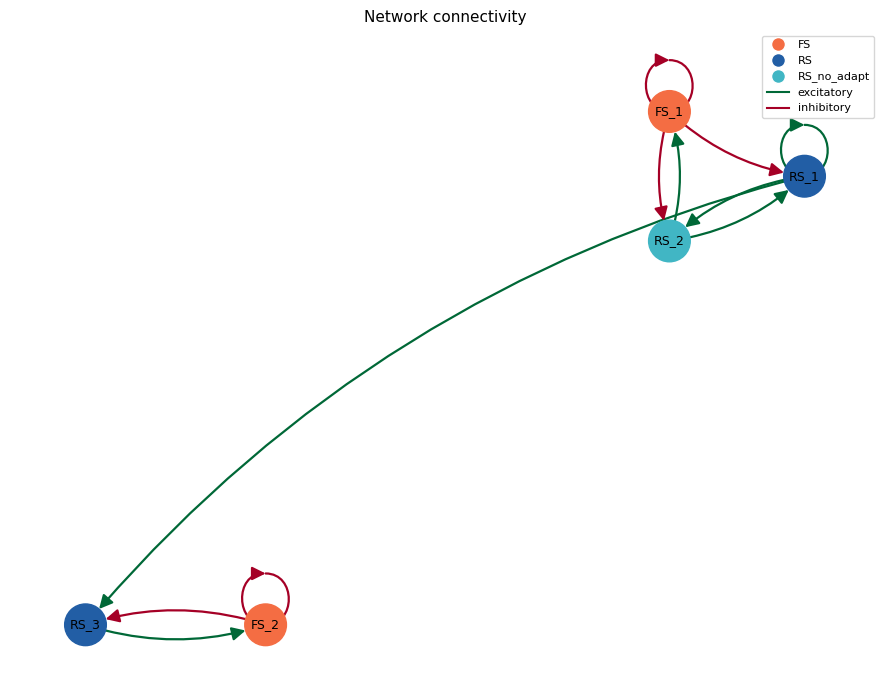

In [4]:
# the connectivity, once - nodes coloured by type, edges by channel (exc/inh)
plot_network(net, save_path="network_scheme.svg")


## External-projection settings

Each population receives an external excitatory (Glutamate) projection; the
effective drive per step is `stimulus * prob * number`. These are derived from
the network (the per-population neuron count sets `number`).

In [5]:
EXT_NUMBER   = {p["name"]: p["N"] for p in net["pops"]}
EXT_PROB     = {name: 0.05 for name in net["names"]}
EXT_RECEPTOR = {name: "Glutamate" for name in net["names"]}


## Stimulus builder

Every population gets a **baseline** background drive; the chosen **signal
targets** additionally get an injected **pulse**.

In [6]:
def make_stimuli(net, time, dt, signal_targets,
                 baseline="ou", baseline_amp= 0.0, baseline_offset=0.4, baseline_sigma=1.0,
                 signal="square", signal_amp=3.0, signal_onset=1.0, signal_offset=1.5,
                 gauss_t0=1.0, gauss_rise=0.02, gauss_decay=0.5,
                 signal_ou_tau=5e-3, signal_ou_sigma=1.0,
                 signal_sin_freq=10.0, signal_sin_amp=5):
    """Return {pop_name: external-input array}.

    baseline : 'ou' (Ornstein-Uhlenbeck + offset), 'const', or 'zero'
    signal   : 'square', 'gaussian', or 'none'  (added only to signal_targets)

    The 'ou' signal is a fluctuating drive with mean `signal_amp`, correlation
    time `signal_ou_tau` and amplitude `signal_ou_sigma`, active in the window
    [signal_onset, signal_offset]. 
    """
    n = len(time)
    signal_targets = set(signal_targets)

    if baseline == "ou":
        base = generate_ou_process(time, dt, baseline_amp, 5e-3, baseline_sigma, 0.0) + baseline_offset
    elif baseline == "const":
        base = np.full(n, baseline_offset)
    else:
        base = np.zeros(n)

    if signal == "square":
        sig = np.zeros(n)
        sig[int(signal_onset / dt):int(signal_offset / dt)] += signal_amp
    elif signal == "gaussian":
        sig = (signal_amp * np.exp(-(time - gauss_t0) ** 2 / (2 * gauss_rise ** 2)) * (time < gauss_t0)
               + signal_amp * np.exp(-(time - gauss_t0) ** 2 / (2 * gauss_decay ** 2)) * (time >= gauss_t0))
    elif signal == "ou":
        ou_sig = generate_ou_process(time, dt, signal_amp, signal_ou_tau, signal_ou_sigma,
                                     x0=signal_amp)
        sig = np.zeros(n)
        w = slice(int(signal_onset / dt), int(signal_offset / dt))
        sig[w] = ou_sig[w]
    elif signal == "ou_sin":
        # baseline at signal_amp, oscillating +- signal_sin_amp at signal_sin_freq, plus zero-mean OU
        carrier = signal_amp + signal_sin_amp * np.sin(2 * np.pi * signal_sin_freq * (time - signal_onset))
        ou_noise = generate_ou_process(time, dt, 0.0, signal_ou_tau, signal_ou_sigma, x0=0.0)
        sig = np.zeros(n)
        w = slice(int(signal_onset / dt), int(signal_offset / dt))
        sig[w] = carrier[w] + ou_noise[w]   
    else:
        sig = np.zeros(n)

    return {name: base + (sig if name in signal_targets else 0.0) for name in net["names"]}


def run(signal_targets, show=True,
        xlim: tuple[float, float] | None = None,
        ylim: tuple[float, float] | None = None,
        save_path: str | None = None,
        **stim_kwargs):
    """Build stimuli for the given targets, simulate (first order), and plot."""
    ext = make_stimuli(net, time, dt, signal_targets, **stim_kwargs)
    out = simulate_MF_network(
        net, time, ext,
        external_number=EXT_NUMBER, external_prob=EXT_PROB,
        external_receptor=EXT_RECEPTOR, tau_f=tau_f, order=1,
    )
    out["net"] = net
    if show or save_path is not None:
        fig, _ = plot_activity(out, net, xlim=xlim, ylim=ylim)
        fig.suptitle(f"signal into: {', '.join(signal_targets)}", y=1.02)
        if save_path is not None:
            fig.savefig(save_path, format="svg", bbox_inches="tight")
        if not show:
            plt.close(fig)
    return out


## ▶ Choose the stimulated population(s)

Here the use can put one or more population names in `SIGNAL_TARGETS` (see the per-node list above), then run this cell and the next.
Stimulate a population in one node and watch the others respond after the edge delays.


In [7]:
SIGNAL_TARGETS = ["RS_1", "RS_2"]     # <-- here the target can be changed


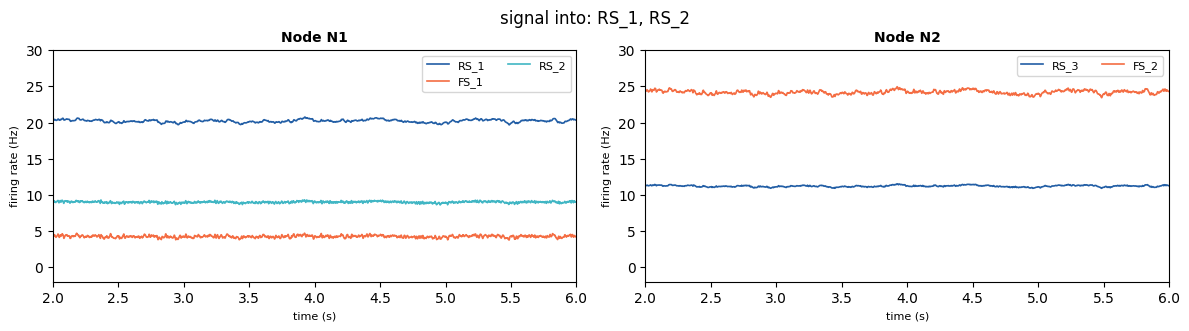

In [8]:
out = run(SIGNAL_TARGETS,baseline="ou", baseline_amp= 0.9, baseline_offset=0.4, baseline_sigma=4.0,
          signal="none", xlim=(2.0, 6.0), ylim=(-2,30),
          save_path="baseline_activity.svg")


## Investigate propagation

Compare a representative excitatory population from each node as the injection
site - the signal appears in the other nodes after the connecting delays.


In [9]:
example_targets = ['RS_1', 'RS_2', 'FS_1']

RS_1
RS_2
FS_1


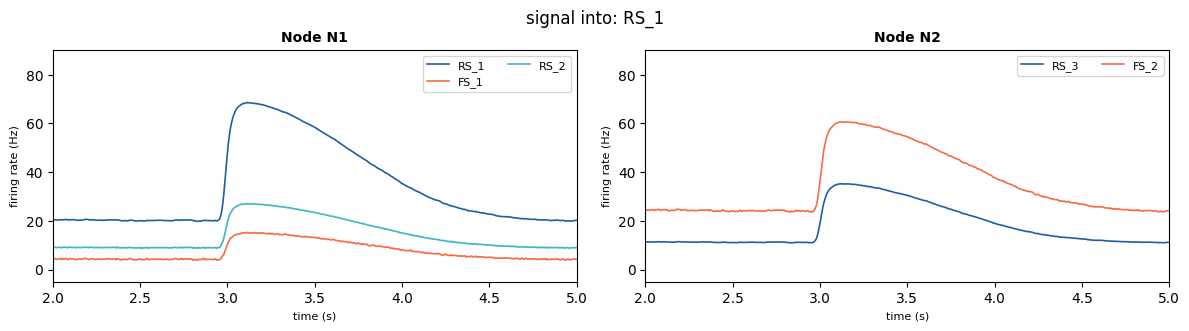

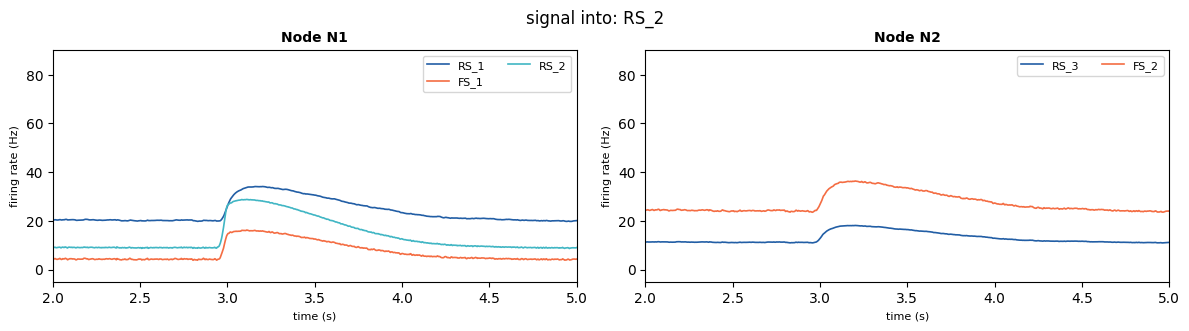

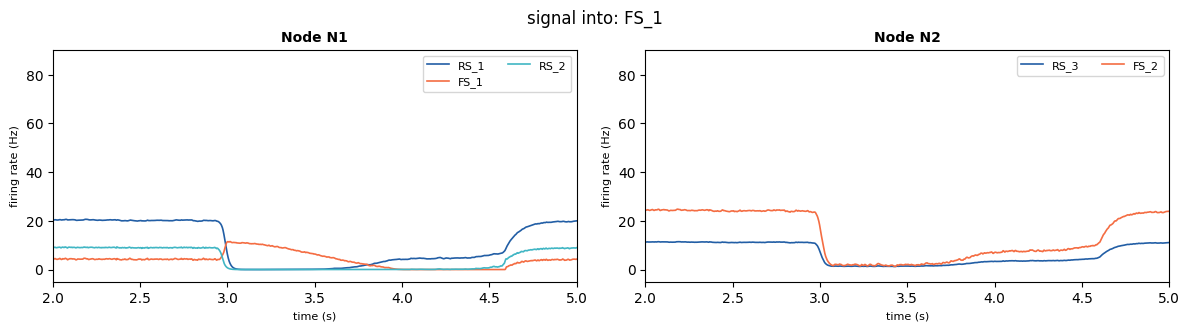

In [10]:
for target in example_targets:
    print(target)
    run([target],baseline="ou", baseline_amp= 0.9, baseline_offset=0.4, baseline_sigma=4.0,
        signal="gaussian", signal_amp=20, gauss_t0=3.0,
        xlim=(2.0, 5.0), ylim=(-5, 90),
        save_path=(f"baseline_activity_gauss_stim_{target}.svg"))


RS_1
RS_2
FS_1


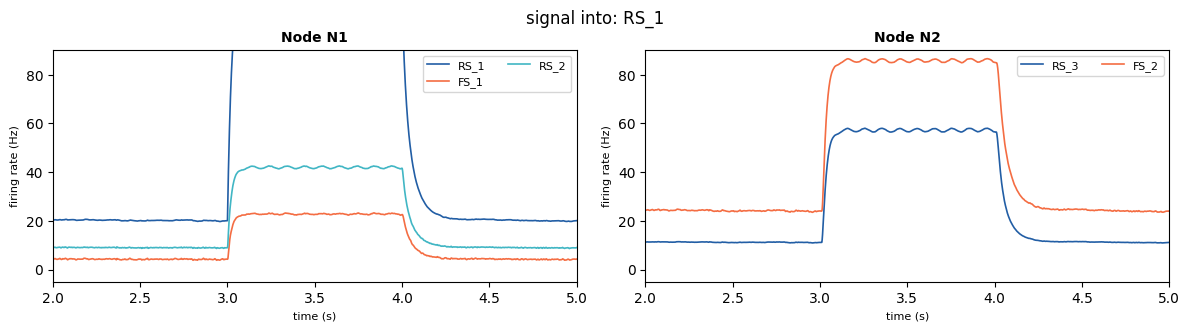

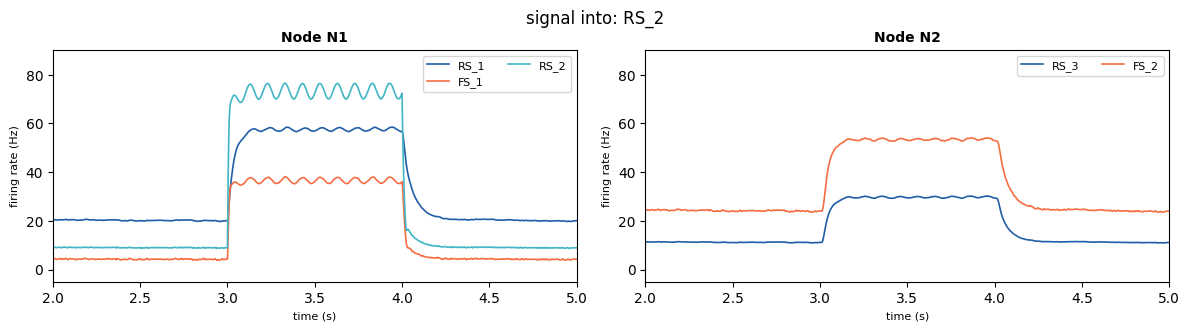

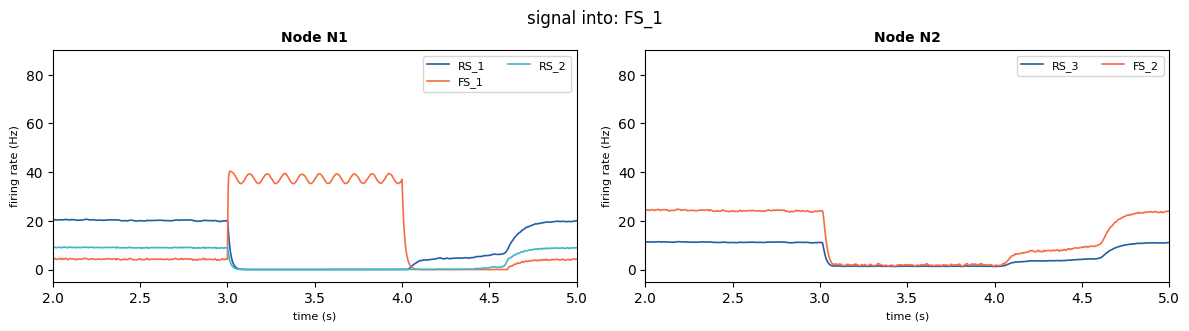

In [11]:
for target in example_targets:
    print(target)
    run([target],baseline="ou", baseline_amp= 0.9, baseline_offset=0.4, baseline_sigma=4.0,
        signal="ou_sin", signal_amp=75, signal_onset=3.0, signal_offset=4,
        xlim=(2.0, 5.0), ylim=(-5, 90),
        save_path=(f"baseline_activity_ou_sin_stim_{target}.svg"))


RS_1
RS_2
FS_1


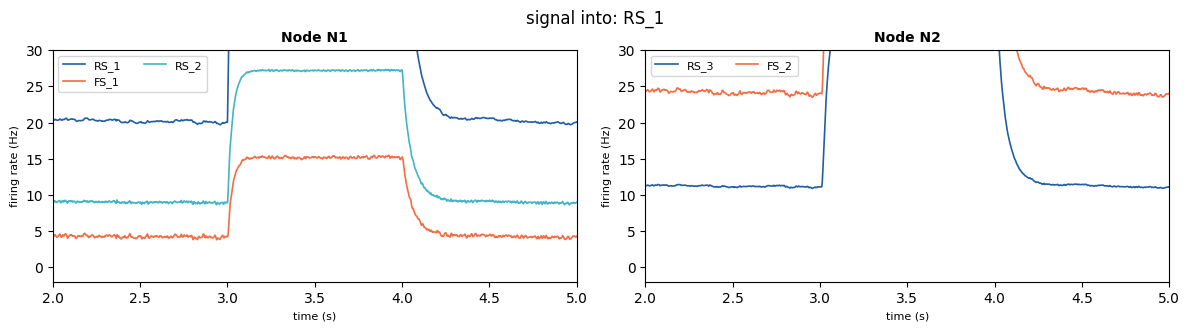

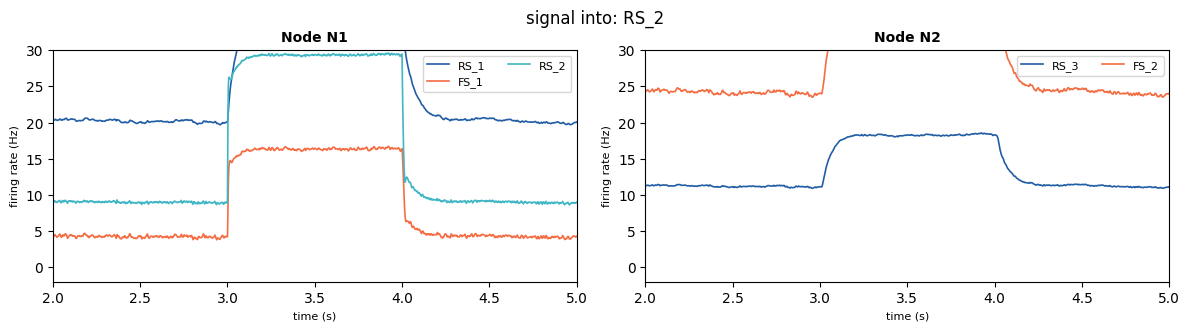

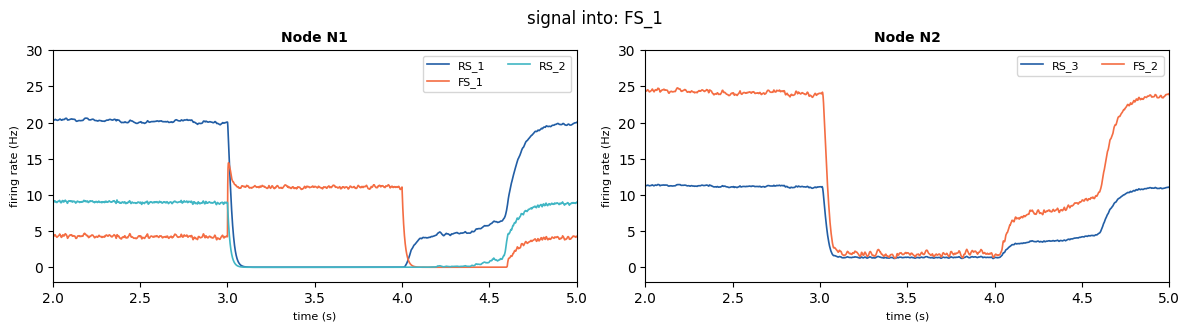

In [12]:
for target in example_targets:
    print(target)
    run([target],baseline="ou", baseline_amp= 0.9, baseline_offset=0.4, baseline_sigma=4.0,
        signal="ou", signal_amp=20, signal_onset=3.0, signal_offset=4.0,
        xlim=(2.0, 5.0), ylim=(-2, 30),
        save_path=(f"baseline_activity_ou_stim_{target}.svg"))
